# ModC Week 4 — Logistic Regression and Feature Scaling

**Domain:** Marketing Conversion Propensity 
**Dataset:** Predict Conversion in Digital Marketing

Logistic regression for binary conversion prediction, with feature scaling comparison and hyperparameter tuning.

## 1. Imports and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

def find_data_root() -> Path:
    marker = 'marketing_and_product_performance.csv'
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / 'data'
        if (data_dir / marker).exists():
            return data_dir
    return Path('data')

DATA_ROOT = find_data_root()

DATASET_PATHS = {
    'Marketing and Product Performance': DATA_ROOT / 'marketing_and_product_performance.csv',
    'Predict Conversion in Digital Marketing': DATA_ROOT / 'digital_marketing_campaign_dataset.csv',
    'Google Ads Sales': DATA_ROOT / 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv',
}

def load_dataset(name: str) -> pd.DataFrame:
    path = DATASET_PATHS[name]
    if not path.exists():
        raise FileNotFoundError(
            f"Missing file for '{name}': {path.resolve()}\n"
            f"Current working directory: {Path.cwd()}\n"
            f"Run: python download_datasets.py"
        )
    df = pd.read_csv(path)
    print(f'{name} loaded: {path.name} | shape={df.shape}')
    return df

def pick_column(df, candidates):
    lower_map = {c.lower().replace(' ', '_'): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(' ', '_')
        if key in lower_map:
            return lower_map[key]
    for col in df.columns:
        norm = col.lower().replace(' ', '_')
        if any(cand.lower().replace(' ', '_') in norm for cand in candidates):
            return col
    return None

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2': r2_score(y_true, y_pred), 'RMSE': rmse}

def clean_currency(series):
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.replace(r'[\$,]', '', regex=True),
            errors='coerce',
        )
    return series

def prepare_google_ads_sales(df):
    prepared = df.copy()
    for col in ['Cost', 'Sale_Amount']:
        if col in prepared.columns:
            prepared[col] = clean_currency(prepared[col])

    target_col = pick_column(prepared, ['Conversions', 'Leads', 'Conversion Rate', 'Sale_Amount'])
    if target_col is None or prepared[target_col].notna().sum() < 100:
        raise ValueError('Could not find a suitable regression target in Google Ads Sales.')
    return prepared, target_col

def build_feature_matrix(df, target_col, max_cat_levels=12):
    model_df = df.dropna(subset=[target_col]).copy()
    id_cols = [c for c in model_df.columns if c.lower().endswith('_id') or c.lower() == 'ad_id']
    model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')

    cat_cols = model_df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        if col != target_col and model_df[col].nunique() <= max_cat_levels:
            model_df = pd.concat([
                model_df.drop(columns=[col]),
                pd.get_dummies(model_df[col], prefix=col, drop_first=True),
            ], axis=1)

    X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X = X.fillna(X.median(numeric_only=True))
    y = model_df[target_col]
    return X, y

predict_conversion = load_dataset('Predict Conversion in Digital Marketing')

Predict Conversion in Digital Marketing loaded: digital_marketing_campaign_dataset.csv | shape=(8000, 20)


## 2. EDA — Conversion Propensity

Conversion
1    0.8765
0    0.1235
Name: proportion, dtype: float64
   CustomerID  Age  Gender  Income CampaignChannel CampaignType      AdSpend  \
0        8000   56  Female  136912    Social Media    Awareness  6497.870068   
1        8001   69    Male   41760           Email    Retention  3898.668606   
2        8002   46  Female   88456             PPC    Awareness  1546.429596   
3        8003   32  Female   44085             PPC   Conversion   539.525936   
4        8004   60  Female   83964             PPC   Conversion  1678.043573   

   ClickThroughRate  ConversionRate  WebsiteVisits  PagesPerVisit  TimeOnSite  \
0          0.043919        0.088031              0       2.399017    7.396803   
1          0.155725        0.182725             42       2.917138    5.352549   
2          0.277490        0.076423              2       8.223619   13.794901   
3          0.137611        0.088004             47       4.540939   14.688363   
4          0.252851        0.109940           

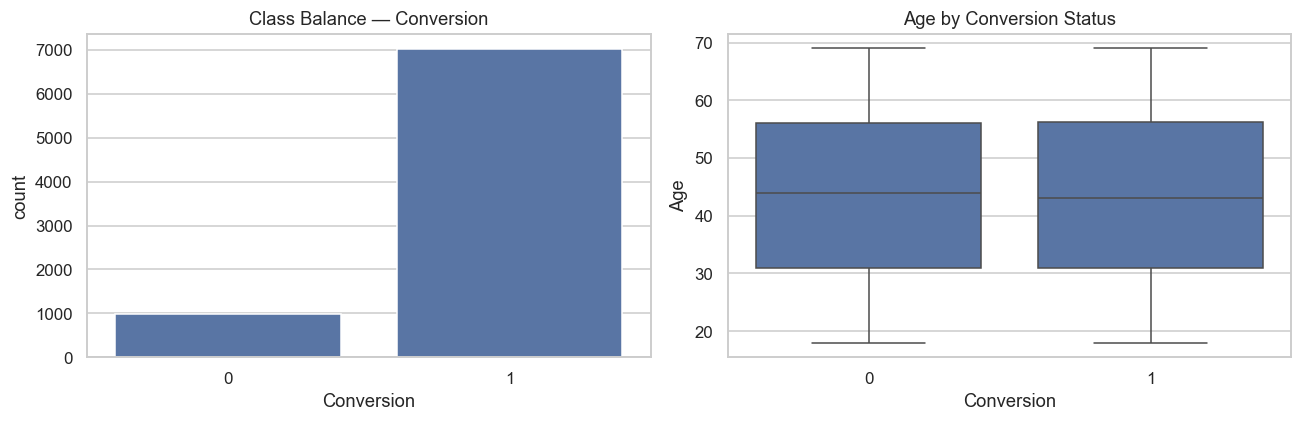

In [2]:

df = predict_conversion.copy()
target_col = pick_column(df, ['Conversion', 'Converted', 'conversion'])
if target_col is None:
    raise ValueError('Could not find binary conversion target in Predict Conversion in Digital Marketing.')

if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype(str).str.lower().map({'yes': 1, 'no': 0, 'true': 1, 'false': 0})
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

print(df[target_col].value_counts(normalize=True))
print(df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x=target_col, ax=axes[0])
axes[0].set_title('Class Balance — Conversion')
axes[0].set_xlabel(target_col)

num_for_plot = pick_column(df, ['Time Spent', 'Time_Spent', 'Page Views', 'Ad Click', 'Age'])
if num_for_plot:
    sns.boxplot(data=df, x=target_col, y=num_for_plot, ax=axes[1])
    axes[1].set_title(f'{num_for_plot} by Conversion Status')
plt.tight_layout()
plt.show()


## 3. Preprocessing

In [3]:

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
model_df = df.dropna(subset=[target_col]).copy()

for col in cat_cols:
    if col != target_col and model_df[col].nunique() <= 15:
        model_df = pd.concat([
            model_df.drop(columns=[col]),
            pd.get_dummies(model_df[col], prefix=col, drop_first=True)
        ], axis=1)

id_cols = [c for c in model_df.columns if c.lower().endswith('id')]
model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')

X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number]).fillna(model_df.median(numeric_only=True))
y = model_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print('Feature count:', X.shape[1])
print('Dropped ID columns:', id_cols)


Feature count: 13
Dropped ID columns: ['CustomerID']


## 4. Feature Scaling Comparison

                  No scaling  StandardScaler  MinMaxScaler
Age                 0.001017       -0.026406     -0.087525
Income              0.000002        0.044536      0.149101
AdSpend             0.000160        0.456389      1.547944
ClickThroughRate    1.305401        0.491939      1.648190
ConversionRate      0.539782        0.364395      1.226755
WebsiteVisits       0.020698        0.302861      1.008378
PagesPerVisit       0.146001        0.377534      1.258664
TimeOnSite          0.121394        0.516925      1.723369
SocialShares        0.000045       -0.047309     -0.155820
EmailOpens          0.075269        0.430754      1.387630


<Figure size 1100x660 with 0 Axes>

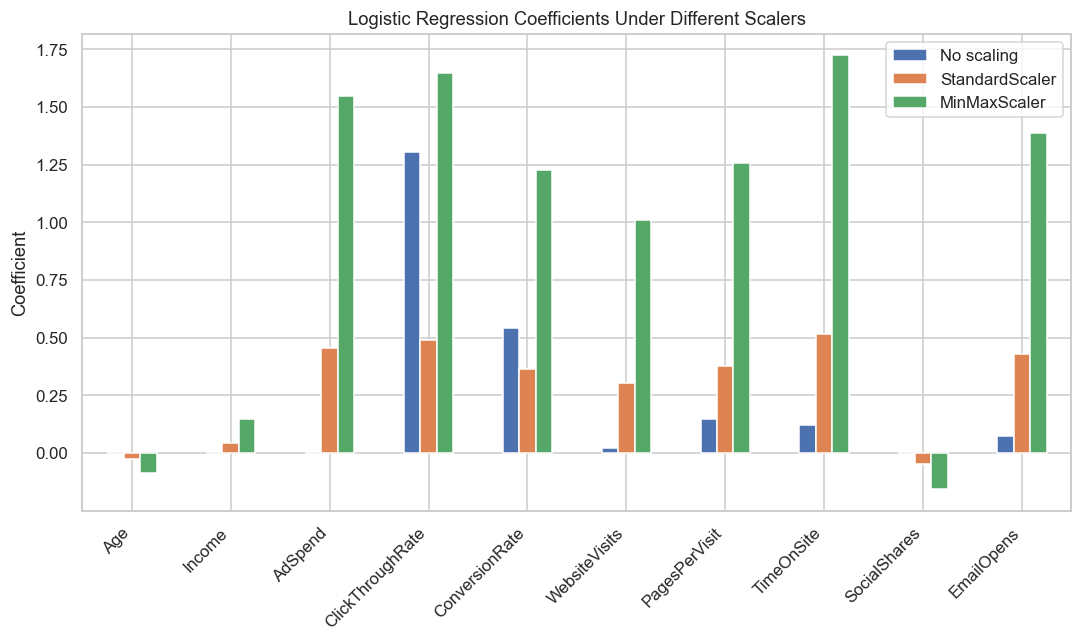

In [4]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

configs = {
    'No scaling': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
}

coef_frames = []
for name, scaler in configs.items():
    if scaler is None:
        Xt = X_train
    else:
        Xt = scaler.fit_transform(X_train)
    lr = LogisticRegression(max_iter=5000, random_state=42)
    lr.fit(Xt, y_train)
    coefs = pd.Series(lr.coef_.ravel(), index=X.columns, name=name)
    coef_frames.append(coefs)

coef_compare = pd.concat(coef_frames, axis=1)
print(coef_compare.head(10))

plt.figure(figsize=(10, 6))
coef_compare.head(10).plot(kind='bar')
plt.title('Logistic Regression Coefficients Under Different Scalers')
plt.ylabel('Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5. Logistic Regression with Hyperparameter Tuning

In [5]:

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, solver='lbfgs'))
])

param_grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best C:', grid.best_params_['clf__C'])
print('Best CV ROC-AUC:', grid.best_score_)

best_model = grid.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)


Best C: 1
Best CV ROC-AUC: 0.791001663530705


## 6. Evaluation Metrics

Accuracy     0.887000
Precision    0.890537
Recall       0.993155
F1           0.939051
ROC-AUC      0.769755
dtype: float64


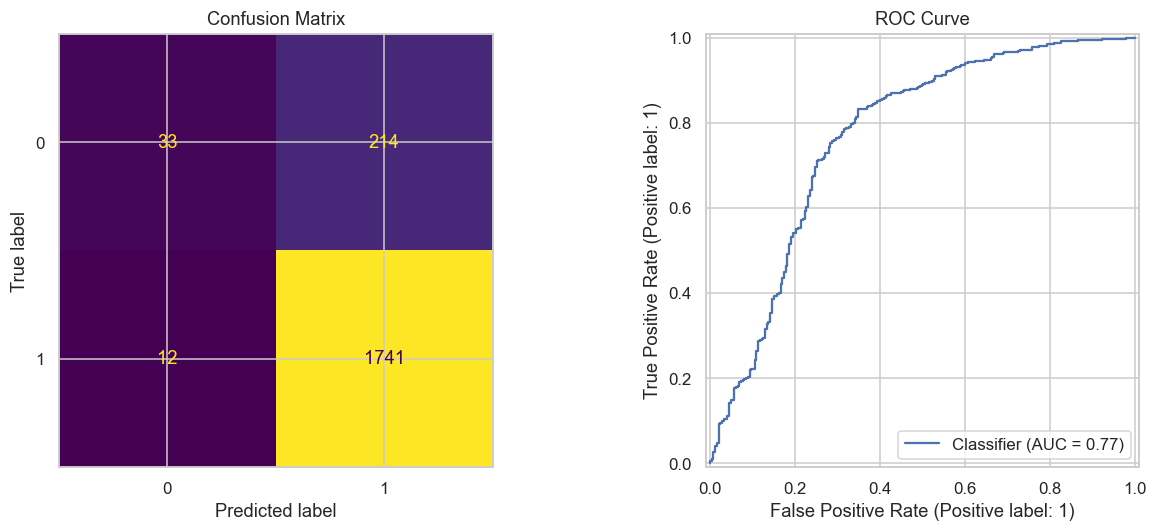

In [6]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
}
print(pd.Series(metrics))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()


## 7. Odds Ratios

              feature  odds_ratio
7          TimeOnSite    1.676864
10        EmailClicks    1.658556
3    ClickThroughRate    1.635484
2             AdSpend    1.578364
11  PreviousPurchases    1.539200
9          EmailOpens    1.538417
12      LoyaltyPoints    1.491661
6       PagesPerVisit    1.458683
4      ConversionRate    1.439643
5       WebsiteVisits    1.353726
1              Income    1.045542
0                 Age    0.973940


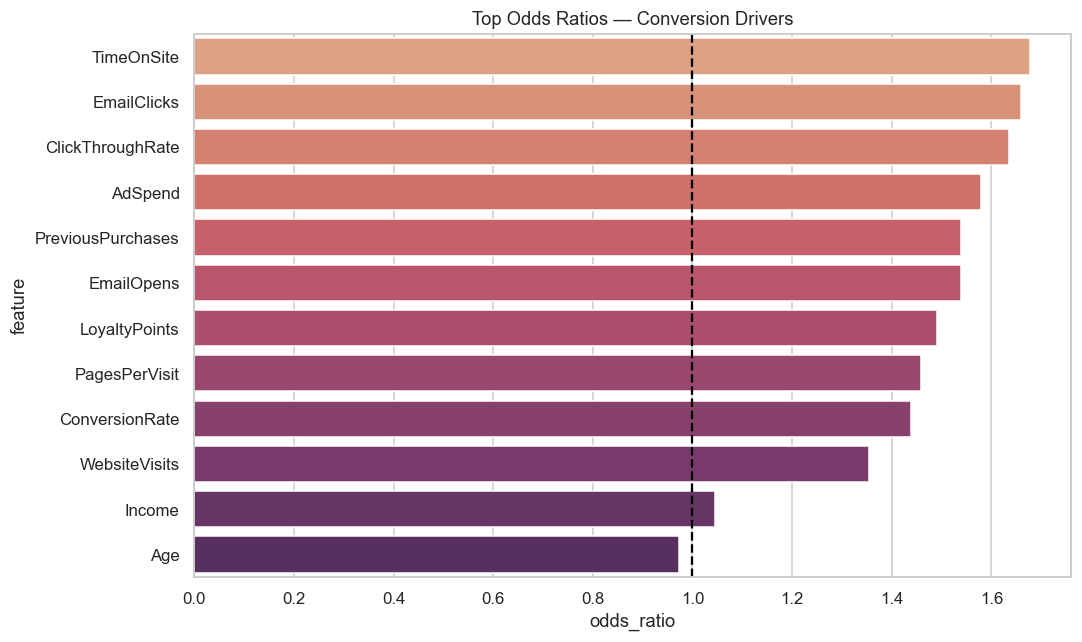

In [7]:

lr_final = best_model.named_steps['clf']
odds = np.exp(lr_final.coef_.ravel())
odds_df = pd.DataFrame({'feature': X.columns, 'odds_ratio': odds})
odds_df = odds_df.sort_values('odds_ratio', ascending=False)
print(odds_df.head(12))

plt.figure(figsize=(10, 6))
top = odds_df.head(12)
sns.barplot(data=top, x='odds_ratio', y='feature', palette='flare')
plt.axvline(1, color='black', linestyle='--')
plt.title('Top Odds Ratios — Conversion Drivers')
plt.tight_layout()
plt.show()


## 8. Conclusions

**EDA:** Class balance guides whether accuracy alone is sufficient; imbalanced conversion rates require recall/precision and ROC-AUC.

**Feature scaling:** Standardizing inputs puts coefficients on comparable scales, making odds ratios and regularization meaningful across age, time spent, and channel indicators.

**Hyperparameter tuning:** Cross-validated `C` controls L2 penalty strength — lower `C` increases regularization and can reduce overfitting on sparse digital behavior features.

**Expected vs unexpected:** Engagement features (time on site, ad clicks) often positively associate with conversion; weak or negative coefficients may indicate audience mismatch or bot traffic segments.

**Business impact:** Features with odds ratios materially above 1 are prime candidates for targeting and creative optimization in B2C/B2B campaigns.